Name : Mushab Ali

Roll no. : 24

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

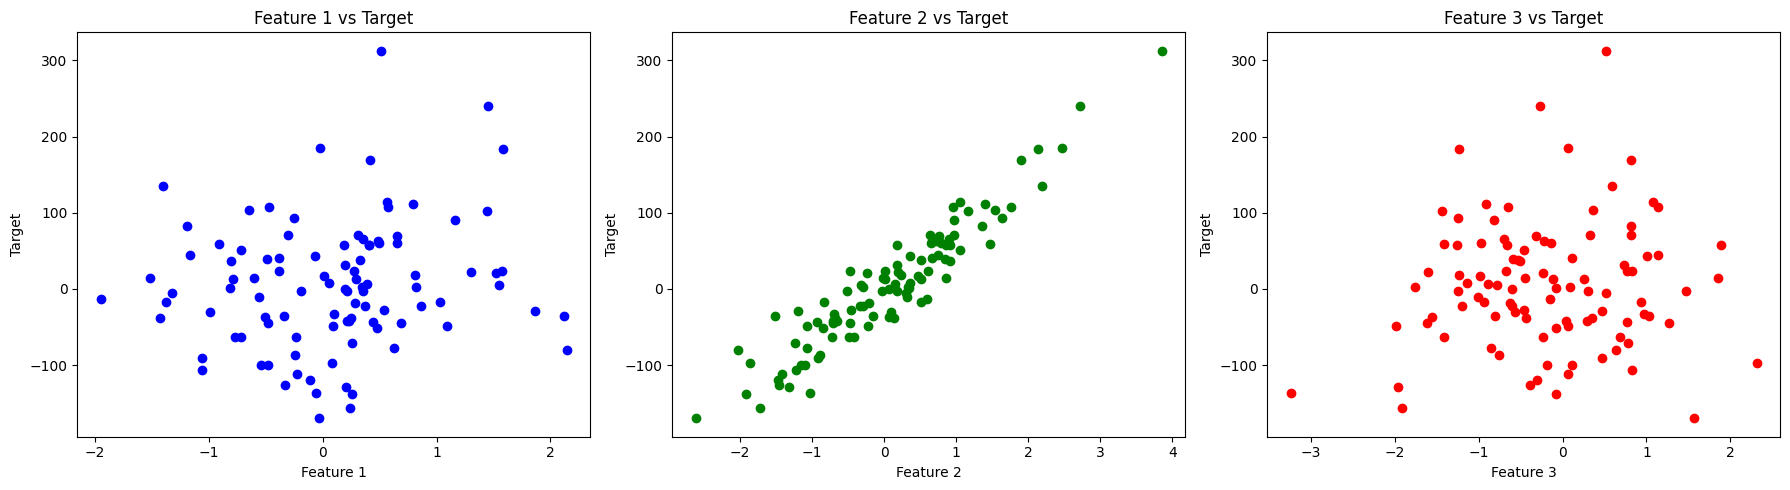

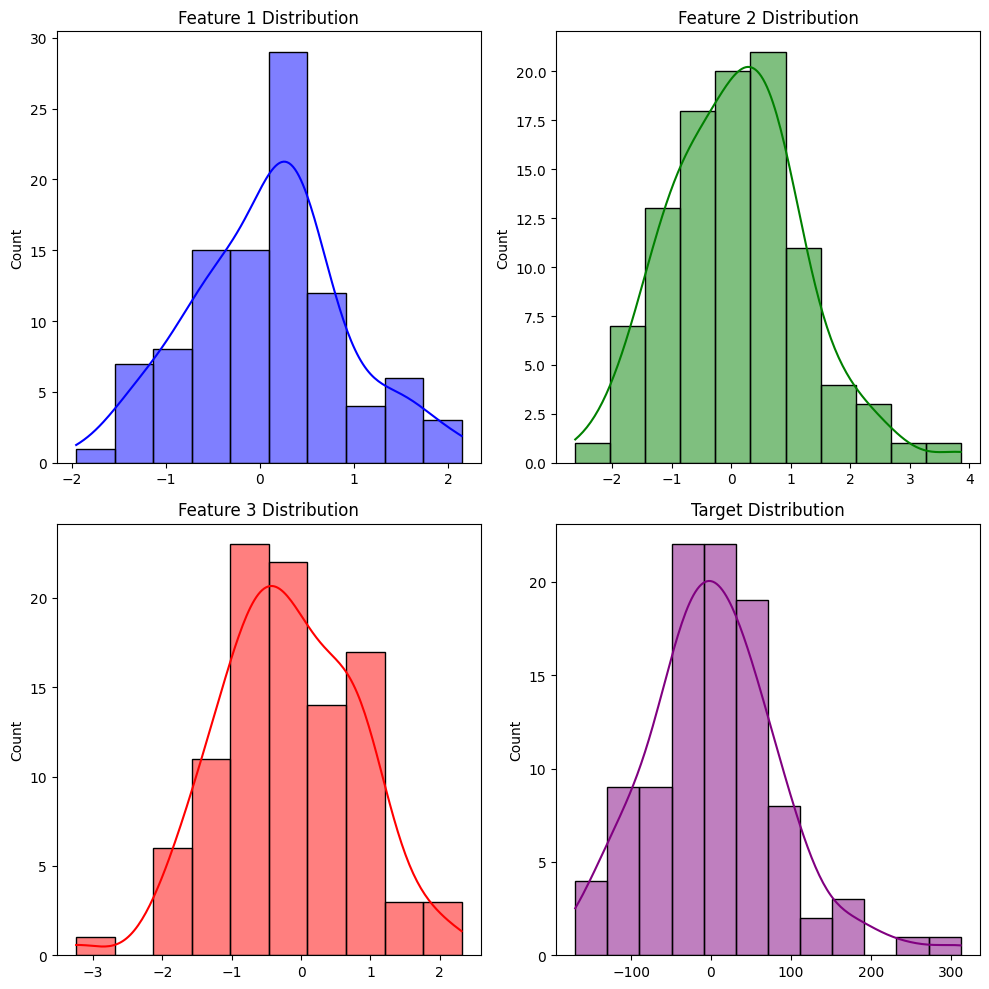

In [4]:
X, y = make_regression(n_samples=100, n_features=3, noise=0.1, random_state=42)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X[:, 0], y, c='b')
axs[0].set_xlabel('Feature 1')
axs[0].set_ylabel('Target')
axs[0].set_title('Feature 1 vs Target')

axs[1].scatter(X[:, 1], y, c='g')
axs[1].set_xlabel('Feature 2')
axs[1].set_ylabel('Target')
axs[1].set_title('Feature 2 vs Target')

axs[2].scatter(X[:, 2], y, c='r')
axs[2].set_xlabel('Feature 3')
axs[2].set_ylabel('Target')
axs[2].set_title('Feature 3 vs Target')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
sns.histplot(X[:, 0], kde=True, ax=axs[0, 0], color='b').set_title('Feature 1 Distribution')
sns.histplot(X[:, 1], kde=True, ax=axs[0, 1], color='g').set_title('Feature 2 Distribution')
sns.histplot(X[:, 2], kde=True, ax=axs[1, 0], color='r').set_title('Feature 3 Distribution')
sns.histplot(y, kde=True, ax=axs[1, 1], color='purple').set_title('Target Distribution')

plt.tight_layout()
plt.show()

In [5]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

In [6]:
def gradient_descent(X, y, eta=0.01, epochs=1000):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros(X_b.shape[1])
    cost_history = []

    for i in range(epochs):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        cost = (1/m) * np.sum((X_b.dot(theta) - y)**2)
        cost_history.append(cost)

    return theta, cost_history

theta, cost_history = gradient_descent(X_normalized, y, eta=0.01, epochs=1000)
print(f"Coefficients (theta): {theta}")

Coefficients (theta): [ 4.96292278 23.14651217 83.10607478 17.29629032]


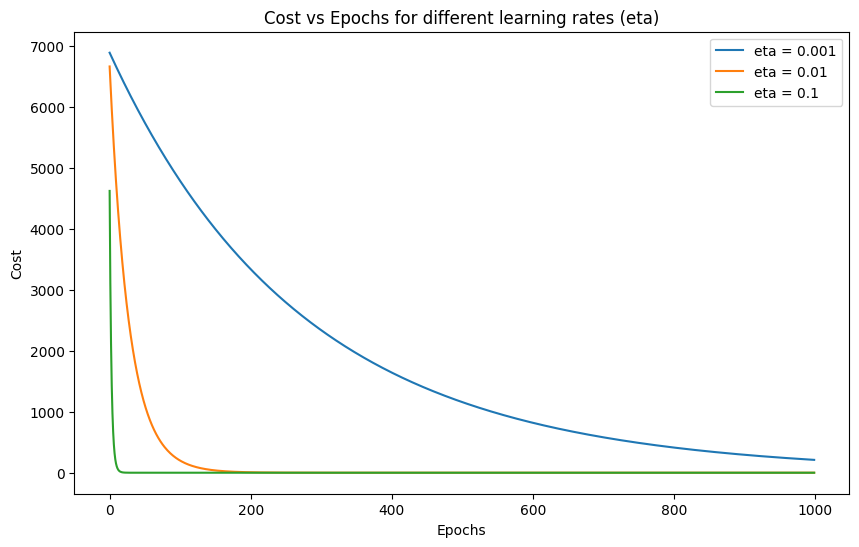

In [7]:
etas = [0.001, 0.01, 0.1]
plt.figure(figsize=(10, 6))

for eta in etas:
    _, cost_history = gradient_descent(X_normalized, y, eta=eta, epochs=1000)
    plt.plot(cost_history, label=f'eta = {eta}')

plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs Epochs for different learning rates (eta)')
plt.legend()
plt.show()

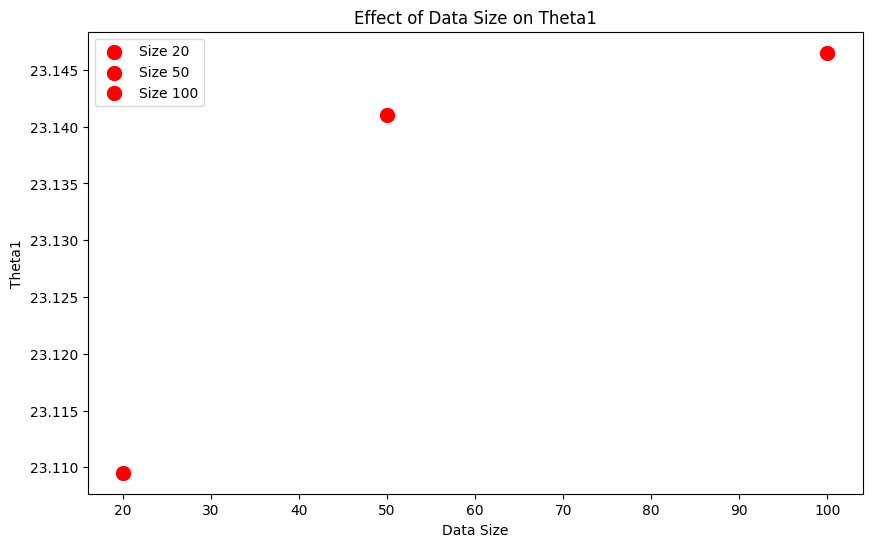

In [8]:
sizes = [20, 50, 100]
plt.figure(figsize=(10, 6))

for size in sizes:
    X_sample, y_sample = X_normalized[:size], y[:size]
    theta, _ = gradient_descent(X_sample, y_sample, eta=0.01, epochs=1000)
    plt.scatter(size, theta[1], label=f'Size {size}', color='r', s=100)

plt.xlabel('Data Size')
plt.ylabel('Theta1')
plt.title('Effect of Data Size on Theta1')
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_normalized, y)
sklearn_theta = np.hstack([model.intercept_, model.coef_])

print(f"Sklearn Coefficients: {sklearn_theta}")
print(f"Gradient Descent Coefficients: {theta}")

Sklearn Coefficients: [ 4.96292279 23.14651606 83.10607961 17.29629427]
Gradient Descent Coefficients: [ 4.96292278 23.14651217 83.10607478 17.29629032]
